   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 69.9 MB/s eta 0:00:00
Mounted at /content/drive
Total rows: 300
Columns: ['ID_Dataset', 'Method', 'Text', 'human_mean']

Unique methods:
Method
Human                 50
temp (0.9)            50
topp (0.95)           50
beam (5)              50
topk (50)             50
CS (('0.6', '10'))    50
Name: count, dtype: int64

Methods found: ['Human' 'temp (0.9)' 'topp (0.95)' 'beam (5)' 'topk (50)'
 "CS (('0.6', '10'))"]
Human: 50 texts
temp (0.9): 50 texts
topp (0.95): 50 texts
beam (5): 50 texts
topk (50): 50 texts
CS (('0.6', '10')): 50 texts

Computing MAUVE scores...

Computing MAUVE for Human vs temp (0.9)...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

Featurizing q:   0%|          | 0/50 [00:00<?, ?it/s]

MAUVE score: 0.0524

Computing MAUVE for Human vs CS (('0.6', '10'))...


Featurizing p:   0%|          | 0/50 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/50 [00:00<?, ?it/s]

MAUVE score: 0.0921

MAUVE computation complete!


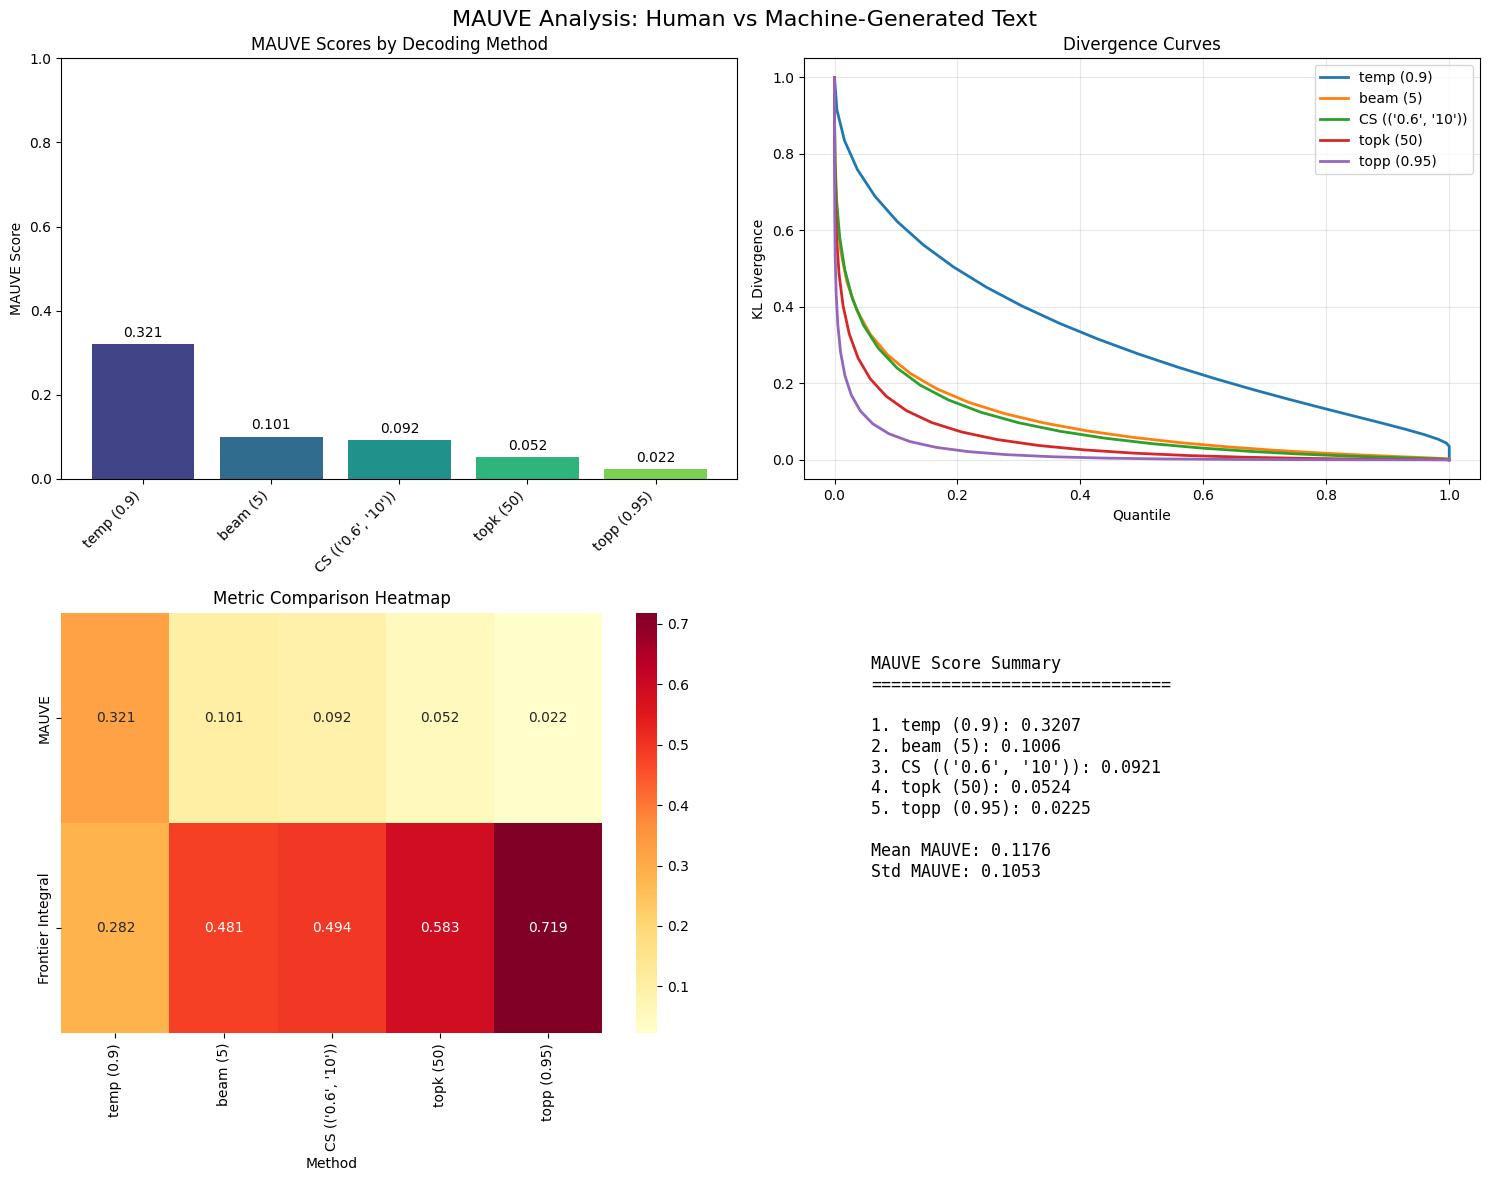


Analyzing correlation with human ratings...

Human ratings distribution:
count    300.000000
mean       2.535000
std        0.904989
min        1.000000
25%        2.000000
50%        2.500000
75%        3.000000
max        4.500000
Name: human_mean, dtype: float64

temp (0.9):
  Spearman correlation: 0.2399
  P-value: 0.0933
  Significant: No

topp (0.95):
  Spearman correlation: 0.2060
  P-value: 0.1512
  Significant: No

beam (5):
  Spearman correlation: 0.1726
  P-value: 0.2305
  Significant: No

topk (50):
  Spearman correlation: 0.1868
  P-value: 0.1940
  Significant: No

CS (('0.6', '10')):
  Spearman correlation: 0.2620
  P-value: 0.0661
  Significant: No

Correlation between MAUVE scores and average human ratings per method:

Spearman correlation (MAUVE vs avg human rating): -0.7000
P-value: 0.1881


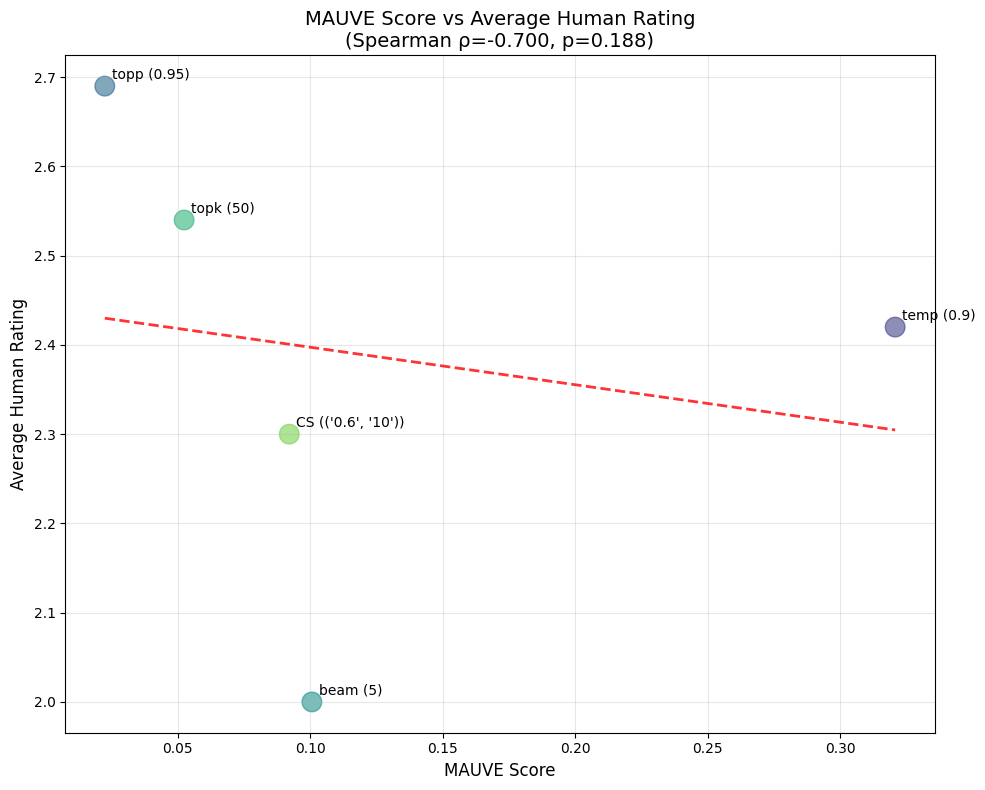


Results saved to: /content/drive/MyDrive/perspectiveNLP/mauve_analysis_results.xlsx
JSON results saved to: /content/drive/MyDrive/perspectiveNLP/mauve_analysis_results.json

MAUVE Analysis Report
Generated: 2025-07-04 23:03:12

EXECUTIVE SUMMARY
-----------------
This analysis compared human-written text continuations against 5 different machine
decoding strategies using the MAUVE metric.

KEY FINDINGS:
1. MAUVE Scores (Human vs Machine):
   1. temp (0.9): 0.3207
   2. beam (5): 0.1006
   3. CS (('0.6', '10')): 0.0921
   4. topk (50): 0.0524
   5. topp (0.95): 0.0225

2. Summary Statistics:
   - Mean MAUVE Score: 0.1176
   - Std Dev: 0.1053
   - Range: [0.0225, 0.3207]

3. Correlation Analysis:
   - MAUVE vs Average Human Rating: ρ=-0.7000 (p=0.1881)
   - This correlation is not statistically significant

INTERPRETATION:
The MAUVE scores indicate how similar each machine decoding strategy's outputs are
to human-written continuations. Higher scores suggest greater similarity to human t

In [1]:
# MAUVE Analysis for Human vs Machine Text Generation

# Install required packages
!pip install mauve-text pandas openpyxl matplotlib seaborn scipy numpy

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import pandas as pd
import numpy as np
from mauve import compute_mauve
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from datetime import datetime
import json

# Define file path
file_path = '/content/drive/MyDrive/perspectiveNLP/text_samples.xlsx'

# Load the data
df = pd.read_excel(file_path)

# Display basic information
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nUnique methods:")
print(df['Method'].value_counts())

# Separate data by method
methods = df['Method'].unique()
print(f"\nMethods found: {methods}")

# Create dictionaries to store texts by method
texts_by_method = {}

for method in methods:
    method_df = df[df['Method'] == method]
    # Combine prompt and continuation for full text
    texts_by_method[method] = [
        row['Text'] for _, row in method_df.iterrows()
    ]
    print(f"{method}: {len(texts_by_method[method])} texts")

# Verify we have 50 texts per method
for method, texts in texts_by_method.items():
    assert len(texts) == 50, f"Expected 50 texts for {method}, got {len(texts)}"

# Get human texts as reference
human_texts = texts_by_method['Human']

# Machine methods (all except Human)
machine_methods = [m for m in methods if m != 'Human']

# Store MAUVE results
mauve_results = {}

print("\nComputing MAUVE scores...")
print("=" * 50)

for method in machine_methods:
    print(f"\nComputing MAUVE for Human vs {method}...")

    # Compute MAUVE score
    out = compute_mauve(
        p_text=human_texts,  # Human texts (reference)
        q_text=texts_by_method[method],  # Machine texts
        device_id=0,  # Use GPU if available
        max_text_length=512,
        verbose=False,
        featurize_model_name="gpt2"
    )

    mauve_results[method] = {
        'mauve': out.mauve,
        'frontier_integral': out.frontier_integral,
        'divergence_curve': out.divergence_curve
    }

    print(f"MAUVE score: {out.mauve:.4f}")

print("\n" + "=" * 50)
print("MAUVE computation complete!")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('MAUVE Analysis: Human vs Machine-Generated Text', fontsize=16)

# 1. Bar plot of MAUVE scores
ax1 = axes[0, 0]
methods_sorted = sorted(mauve_results.keys(), key=lambda x: mauve_results[x]['mauve'], reverse=True)
mauve_scores = [mauve_results[m]['mauve'] for m in methods_sorted]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(methods_sorted)))

bars = ax1.bar(range(len(methods_sorted)), mauve_scores, color=colors)
ax1.set_xticks(range(len(methods_sorted)))
ax1.set_xticklabels(methods_sorted, rotation=45, ha='right')
ax1.set_ylabel('MAUVE Score')
ax1.set_title('MAUVE Scores by Decoding Method')
ax1.set_ylim(0, 1)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, mauve_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# 2. Divergence curves
ax2 = axes[0, 1]
for method in methods_sorted:
    curve = mauve_results[method]['divergence_curve']
    ax2.plot(curve[:, 0], curve[:, 1], label=method, linewidth=2)
ax2.set_xlabel('Quantile')
ax2.set_ylabel('KL Divergence')
ax2.set_title('Divergence Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Heatmap of results
ax3 = axes[1, 0]
results_matrix = pd.DataFrame({
    'Method': methods_sorted,
    'MAUVE': mauve_scores,
    'Frontier Integral': [mauve_results[m]['frontier_integral'] for m in methods_sorted]
})
results_pivot = results_matrix.set_index('Method').T
sns.heatmap(results_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax3)
ax3.set_title('Metric Comparison Heatmap')

# 4. Summary statistics
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = "MAUVE Score Summary\n" + "="*30 + "\n\n"
for i, method in enumerate(methods_sorted):
    summary_text += f"{i+1}. {method}: {mauve_results[method]['mauve']:.4f}\n"
summary_text += f"\nMean MAUVE: {np.mean(mauve_scores):.4f}"
summary_text += f"\nStd MAUVE: {np.std(mauve_scores):.4f}"
ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes,
         fontsize=12, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/perspectiveNLP/mauve_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyze correlation with human ratings
print("\nAnalyzing correlation with human ratings...")
print("=" * 50)

# Understand the human ratings structure
print("\nHuman ratings distribution:")
print(df['human_mean'].describe())

# Create a comprehensive analysis
correlation_results = {}

# For each method, calculate correlation with human ratings
for method in machine_methods:
    method_df = df[df['Method'] == method]

    # Ensure proper alignment by ID
    method_ratings = method_df.set_index('ID_Dataset')['human_mean'].sort_index()

    # Get corresponding human texts ratings for comparison
    human_df = df[df['Method'] == 'Human']
    human_ratings = human_df.set_index('ID_Dataset')['human_mean'].sort_index()

    # Ensure we have matching IDs
    common_ids = method_ratings.index.intersection(human_ratings.index)

    if len(common_ids) > 0:
        # Calculate Spearman correlation
        corr, p_value = stats.spearmanr(
            method_ratings.loc[common_ids],
            human_ratings.loc[common_ids]
        )

        correlation_results[method] = {
            'correlation': corr,
            'p_value': p_value,
            'n_samples': len(common_ids)
        }

        print(f"\n{method}:")
        print(f"  Spearman correlation: {corr:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")

# Additional analysis: correlation between MAUVE scores and average human ratings per method
print("\n" + "="*50)
print("Correlation between MAUVE scores and average human ratings per method:")

# Calculate average human rating per method
avg_ratings_by_method = {}
for method in machine_methods:
    method_df = df[df['Method'] == method]
    avg_ratings_by_method[method] = method_df['human_mean'].mean()

# Prepare data for correlation
mauve_scores_list = [mauve_results[m]['mauve'] for m in machine_methods]
avg_ratings_list = [avg_ratings_by_method[m] for m in machine_methods]

# Calculate correlation
corr_mauve_rating, p_mauve_rating = stats.spearmanr(mauve_scores_list, avg_ratings_list)
print(f"\nSpearman correlation (MAUVE vs avg human rating): {corr_mauve_rating:.4f}")
print(f"P-value: {p_mauve_rating:.4f}")

# Visualize correlation
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Scatter plot
scatter = ax.scatter(mauve_scores_list, avg_ratings_list, s=200, alpha=0.6, c=colors)

# Add method labels
for i, method in enumerate(machine_methods):
    ax.annotate(method, (mauve_scores_list[i], avg_ratings_list[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

# Add trend line
z = np.polyfit(mauve_scores_list, avg_ratings_list, 1)
p = np.poly1d(z)
ax.plot(sorted(mauve_scores_list), p(sorted(mauve_scores_list)), "r--", alpha=0.8, linewidth=2)

ax.set_xlabel('MAUVE Score', fontsize=12)
ax.set_ylabel('Average Human Rating', fontsize=12)
ax.set_title(f'MAUVE Score vs Average Human Rating\n(Spearman ρ={corr_mauve_rating:.3f}, p={p_mauve_rating:.3f})',
             fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/perspectiveNLP/mauve_vs_human_rating_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a comprehensive results dictionary
comprehensive_results = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'mauve_scores': {},
    'correlation_analysis': correlation_results,
    'mauve_rating_correlation': {
        'correlation': corr_mauve_rating,
        'p_value': p_mauve_rating
    },
    'summary_statistics': {
        'mean_mauve': np.mean(mauve_scores),
        'std_mauve': np.std(mauve_scores),
        'min_mauve': np.min(mauve_scores),
        'max_mauve': np.max(mauve_scores)
    }
}

# Add MAUVE scores
for method in machine_methods:
    comprehensive_results['mauve_scores'][method] = {
        'mauve': mauve_results[method]['mauve'],
        'frontier_integral': mauve_results[method]['frontier_integral']
    }

# Save results to Excel
results_df = pd.DataFrame([
    {
        'Method': method,
        'MAUVE_Score': mauve_results[method]['mauve'],
        'Frontier_Integral': mauve_results[method]['frontier_integral'],
        'Avg_Human_Rating': avg_ratings_by_method[method],
        'Correlation_with_Human': correlation_results.get(method, {}).get('correlation', np.nan),
        'Correlation_P_Value': correlation_results.get(method, {}).get('p_value', np.nan)
    }
    for method in machine_methods
])

results_df = results_df.sort_values('MAUVE_Score', ascending=False)

# Save to Excel
output_path = '/content/drive/MyDrive/perspectiveNLP/mauve_analysis_results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='MAUVE_Results', index=False)

    # Add a summary sheet
    summary_df = pd.DataFrame([comprehensive_results['summary_statistics']])
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print(f"\nResults saved to: {output_path}")

# Save as JSON for programmatic access
json_path = '/content/drive/MyDrive/perspectiveNLP/mauve_analysis_results.json'
with open(json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print(f"JSON results saved to: {json_path}")

# Generate a text report
report = f"""
MAUVE Analysis Report
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*60}

EXECUTIVE SUMMARY
-----------------
This analysis compared human-written text continuations against 5 different machine
decoding strategies using the MAUVE metric.

KEY FINDINGS:
1. MAUVE Scores (Human vs Machine):
"""

for i, method in enumerate(methods_sorted):
    report += f"   {i+1}. {method}: {mauve_results[method]['mauve']:.4f}\n"

report += f"""
2. Summary Statistics:
   - Mean MAUVE Score: {np.mean(mauve_scores):.4f}
   - Std Dev: {np.std(mauve_scores):.4f}
   - Range: [{np.min(mauve_scores):.4f}, {np.max(mauve_scores):.4f}]

3. Correlation Analysis:
   - MAUVE vs Average Human Rating: ρ={corr_mauve_rating:.4f} (p={p_mauve_rating:.4f})
   - This correlation is {'statistically significant' if p_mauve_rating < 0.05 else 'not statistically significant'}

INTERPRETATION:
The MAUVE scores indicate how similar each machine decoding strategy's outputs are
to human-written continuations. Higher scores suggest greater similarity to human text.

{'='*60}
"""

# Save report
report_path = '/content/drive/MyDrive/perspectiveNLP/mauve_analysis_report.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\nReport saved to: {report_path}")

print("\n✅ All analyses complete! Check your perspectiveNLP folder for:")
print("  - mauve_analysis_visualization.png")
print("  - mauve_vs_human_rating_correlation.png")
print("  - mauve_analysis_results.xlsx")
print("  - mauve_analysis_results.json")
print("  - mauve_analysis_report.txt")